In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv('/content/drive/MyDrive/fraud_project/PS_20174392719_1491204439457_log.csv')
print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (6362620, 11)


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
print("Fraud vs Not Fraud:")
print(df['isFraud'].value_counts())
print("")
print("Fraud percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)

Fraud vs Not Fraud:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


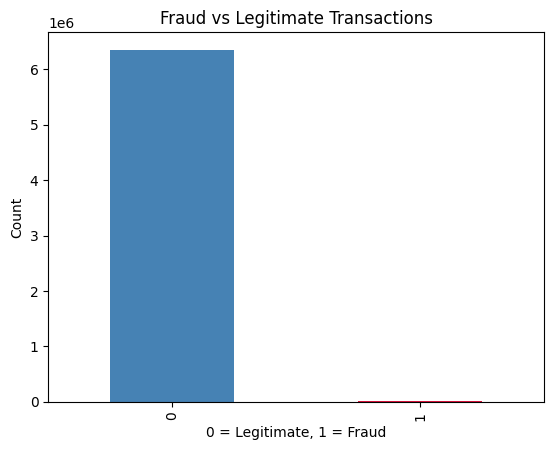

In [8]:
df['isFraud'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('0 = Legitimate, 1 = Fraud')
plt.ylabel('Count')
plt.show()

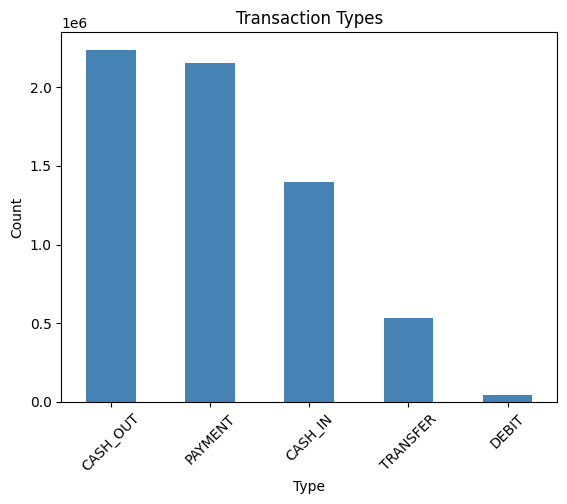

In [9]:
df['type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Transaction Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Fraud count by transaction type:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


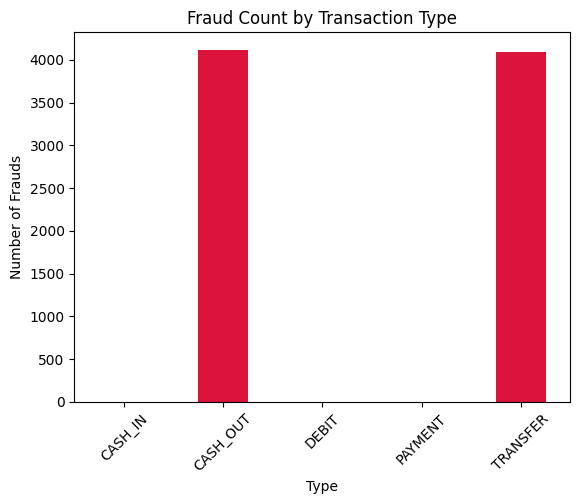

In [10]:
fraud_by_type = df.groupby('type')['isFraud'].sum()
print("Fraud count by transaction type:")
print(fraud_by_type)

fraud_by_type.plot(kind='bar', color='crimson')
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Type')
plt.ylabel('Number of Frauds')
plt.xticks(rotation=45)
plt.show()

Fraud count by transaction type:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


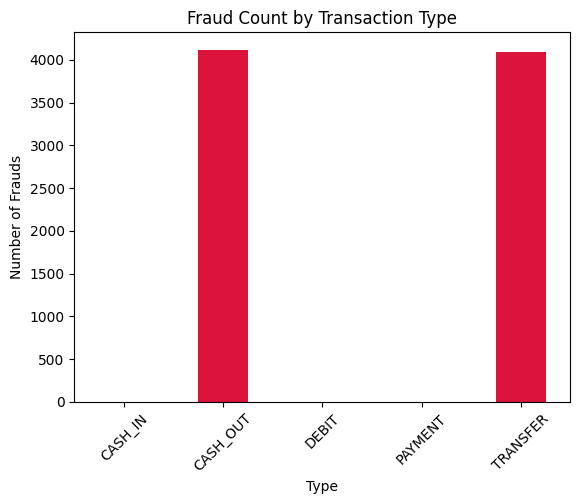

In [11]:
fraud_by_type = df.groupby('type')['isFraud'].sum()
print("Fraud count by transaction type:")
print(fraud_by_type)

fraud_by_type.plot(kind='bar', color='crimson')
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Type')
plt.ylabel('Number of Frauds')
plt.xticks(rotation=45)
plt.show()

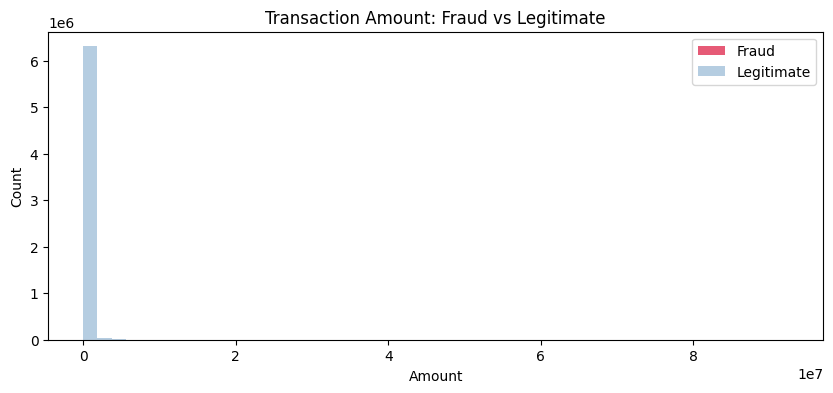

In [12]:
fraud = df[df['isFraud'] == 1]
legit = df[df['isFraud'] == 0]

plt.figure(figsize=(10, 4))
plt.hist(fraud['amount'], bins=50, color='crimson', alpha=0.7, label='Fraud')
plt.hist(legit['amount'], bins=50, color='steelblue', alpha=0.4, label='Legitimate')
plt.title('Transaction Amount: Fraud vs Legitimate')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.legend()
plt.show()

In [13]:
# Filter only CASH_OUT and TRANSFER (only types with fraud)
df_model = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
print("Shape after filtering:", df_model.shape)
print("Fraud cases:", df_model['isFraud'].sum())

Shape after filtering: (2770409, 11)
Fraud cases: 8213


In [14]:
df_model['type_encoded'] = (df_model['type'] == 'TRANSFER').astype(int)
print("Type encoding done!")
print(df_model['type_encoded'].value_counts())

Type encoding done!
type_encoded
0    2237500
1     532909
Name: count, dtype: int64


In [15]:
# Select features and target
X = df_model[['type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
y = df_model['isFraud']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2770409, 6)
Target shape: (2770409,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2216327, 6)
Testing size: (554082, 6)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2216327, 6)
Testing size: (554082, 6)


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552436
           1       0.97      0.78      0.86      1646

    accuracy                           1.00    554082
   macro avg       0.98      0.89      0.93    554082
weighted avg       1.00      1.00      1.00    554082



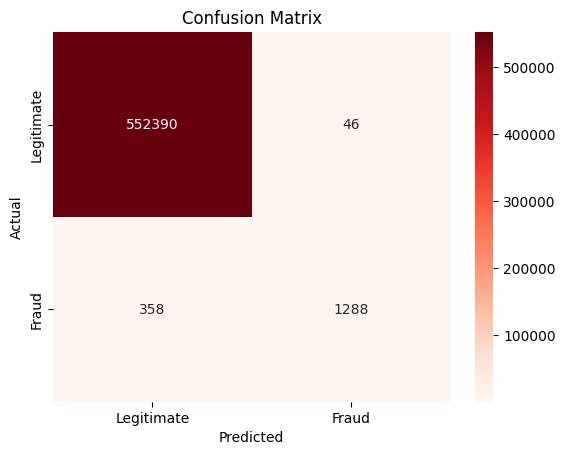

In [20]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

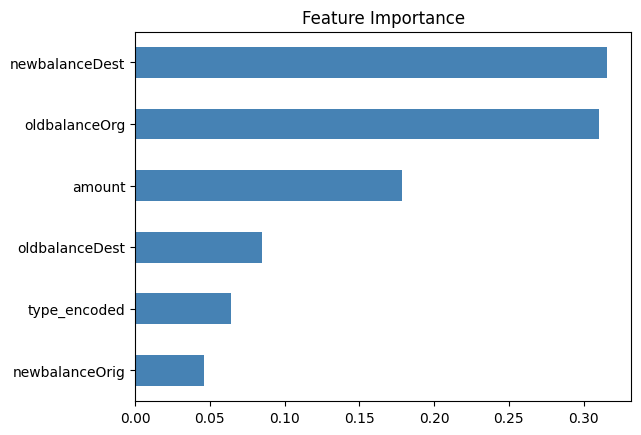

In [21]:
feat_importance = pd.Series(model.feature_importances_,
                            index=X.columns)
feat_importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.show()

In [22]:
import joblib
joblib.dump(model, '/content/drive/MyDrive/fraud_project/fraud_model.pkl')
print("Model saved to Google Drive!")

Model saved to Google Drive!


In [23]:
import numpy as np
sample = np.array([[1, 500000, 500000, 0, 0, 500000]])
prediction = model.predict(sample)
probability = model.predict_proba(sample)
if prediction[0] == 1:
    print("FRAUD DETECTED!")
else:
    print("LEGITIMATE TRANSACTION")
print(f"Fraud probability: {probability[0][1]*100:.2f}%")

LEGITIMATE TRANSACTION
Fraud probability: 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
